# Chapter 24: The Anomaly
A level shift breaks a stable process. Use only past observations to produce
forecasts and CUSUM alarms; compare adaptation policies on the same stream.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
rng=begin(24); y=np.r_[rng.normal(50,2,100),rng.normal(65,2,100)]; origin=50
baseline=y[:origin].mean(); sd=y[:origin].std(ddof=1)

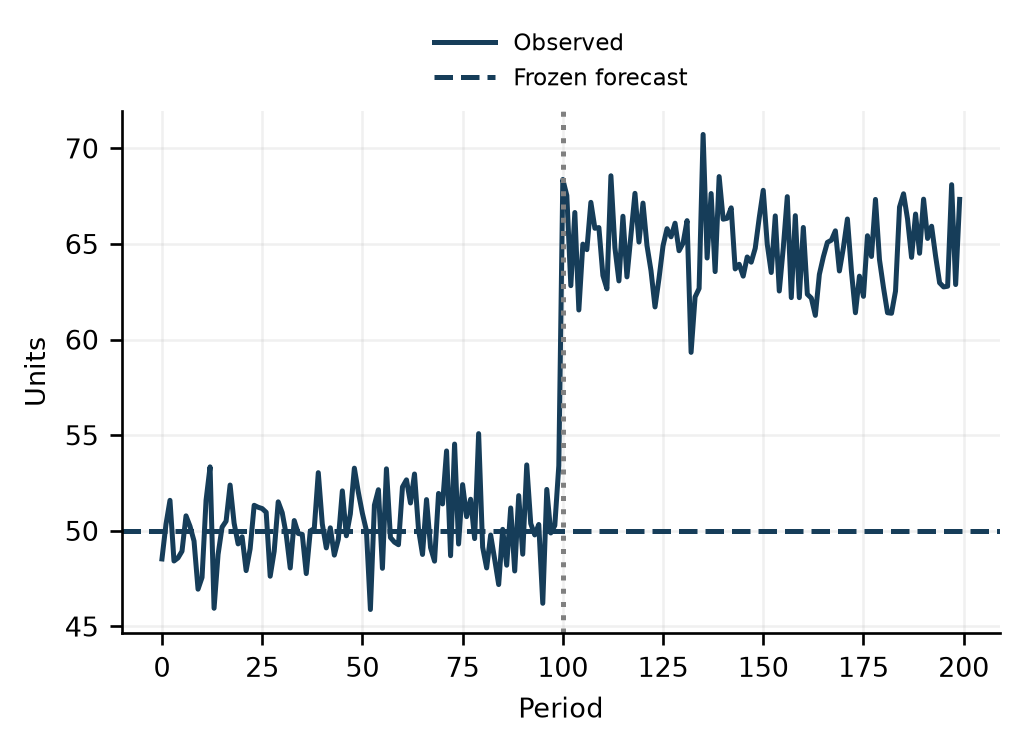

In [2]:
plt.figure(); plt.plot(y,label='Observed'); plt.axhline(baseline,label='Frozen forecast',ls='--'); plt.axvline(100,color='.5',ls=':'); plt.xlabel('Period'); plt.ylabel('Units'); plt.legend(fontsize=7)
save(24,1,'The old model keeps predicting the old world','Synthetic series with a level increase at period 100. The frozen model is estimated only on the first fifty observations.','## Section One: The Dashboard Turns Red')

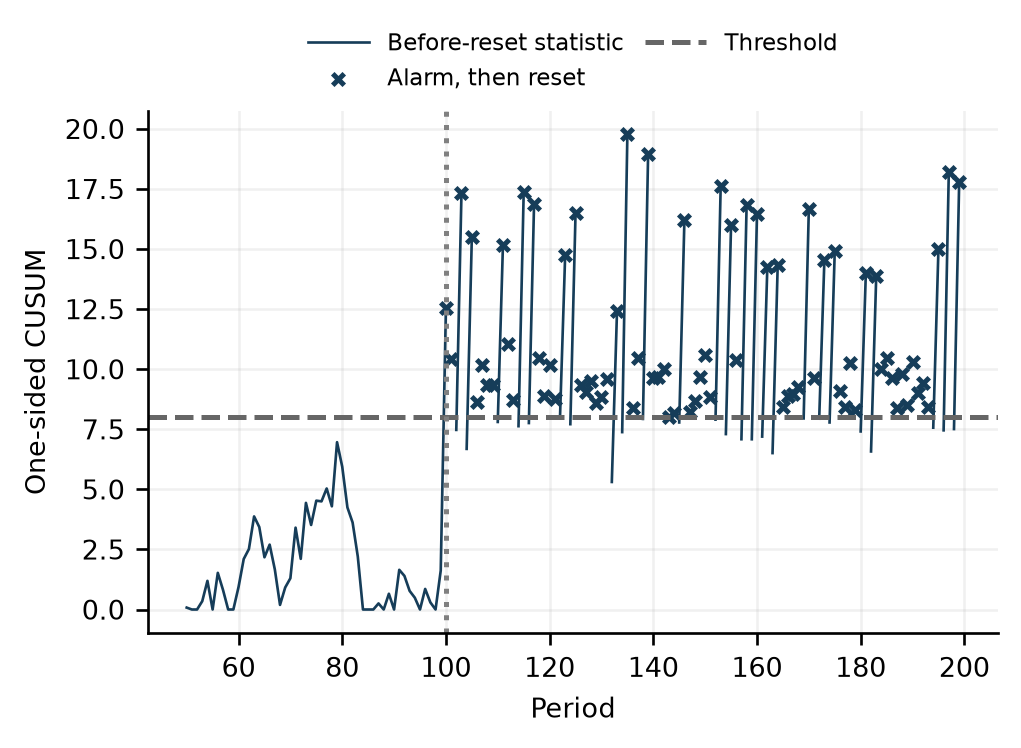

In [3]:
stat=[]; s=0.; alarms=[]; threshold=8.
for t in range(origin,len(y)):
    s=max(0,s+(y[t]-baseline)/sd-.5); stat.append(s)
    if s>threshold: alarms.append(t); s=0
plt.figure()
# Values are recorded BEFORE reset. Break lines after alarms so resets are visible.
plot_time=[]; plot_stat=[]
for period,value in zip(range(origin,len(y)),stat):
    plot_time.append(period); plot_stat.append(value)
    if period in alarms: plot_time.append(period+.01); plot_stat.append(np.nan)
plt.plot(plot_time,plot_stat,label='Before-reset statistic',lw=.8)
plt.scatter(alarms,[stat[t-origin] for t in alarms],marker='x',s=12,label='Alarm, then reset')
plt.axhline(threshold,ls='--',color='.4',label='Threshold'); plt.axvline(100,color='.5',ls=':')
plt.xlabel('Period'); plt.ylabel('One-sided CUSUM'); plt.legend(fontsize=6)
save(24,2,'An alarm accumulates evidence','Online standardized residual CUSUM on the synthetic stream. Values are recorded before resetting to zero after each marked alarm; connecting lines break at resets. Each alarm is available only after its observation; the threshold is illustrative.','## Section Three: Building for Structural Breaks')

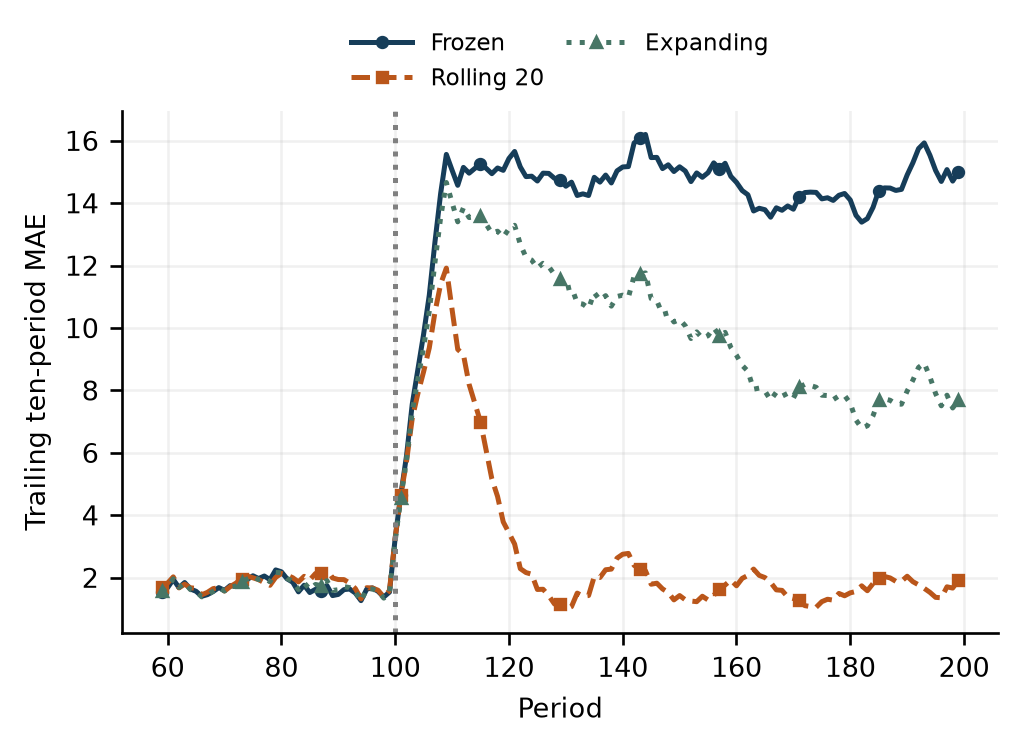

Pre-break false alarms: 0 first post-break delay: 0


In [4]:
predictions={'Frozen':np.repeat(baseline,150),'Rolling 20':np.array([y[t-20:t].mean() for t in range(50,200)]),'Expanding':np.array([y[:t].mean() for t in range(50,200)])}
plt.figure()
for name,pred in predictions.items():
    err=abs(pred-y[50:]); rolling=np.convolve(err,np.ones(10)/10,mode='valid'); plt.plot(np.arange(59,200),rolling,label=name)
plt.axvline(100,color='.5',ls=':'); plt.xlabel('Period'); plt.ylabel('Trailing ten-period MAE'); plt.legend(fontsize=7)
save(24,3,'Adaptation policies have different costs','Synthetic one-step forecasts computed before each observation. Rolling windows adapt faster here but discard data that could help in stable periods.','## Section Four: The Full Methodology')
print('Pre-break false alarms:',sum(t<100 for t in alarms),'first post-break delay:',min(t for t in alarms if t>=100)-100)

## Limits and exercise
Replace the abrupt shift with slow drift or a temporary outlier. Recalibrate
thresholds using separate stable data before operational use. L1 penalizes the
sum of absolute coefficients; it is not the count of nonzero coefficients.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
A regular series with at least 80 observations. `calibration_size` names the opening window believed to be a stable regime; the CUSUM mean and standard deviation come from it, so choose it before looking at the later data. Seasonal series should be deseasonalised first, or the seasonal swings will be dated as breaks.

Minimal **format illustration**, not sufficient training data:

```csv
timestamp,target
1871-01-01,1120
1872-01-01,1160
1873-01-01,963
```

## Explain the mechanism

A detector accumulates evidence that the existing model no longer fits. It does not identify the cause. Operational value depends on what happens after an alarm and on the costs of both needless changes and delayed adaptation.

## Work through the arithmetic

For k=.5, threshold h=3 and standardized residuals [1,2,2], CUSUM values before reset are [.5,2,3.5]. The third observation triggers an alarm; the next update starts from zero under a resetting policy. Drawing a continuous line from 3.5 without showing the reset can misrepresent the detector.

## Adapt the lesson to reader data

Replace the generated series while preserving the initial training and subsequent monitoring split. Plot alarm markers and reset-aware paths. The original lesson used an illustrative threshold and no alarm-triggered override; the applied interface must explicitly report which calibration and policies it actually runs.

For this chapter, settle these questions before fitting: What stable period can calibrate the detector? What false-alarm burden is tolerable? Which errors are available online? What action follows the first alarm? Could the anomaly be bad data?

## Interpret the actual lesson outputs

The original controlled level shift occurs at period 100. Its frozen/rolling/expanding curves use past observations. A resetting detector can produce many later alarms, so the first post-break delay and the action after that alarm matter more than raw alarm count alone.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,actual,frozen,rolling,expanding,adaptive,cusum_before_reset,alarm,rolling_mean,rolling_var,mean_shift_sd,variance_ratio,segment_id`.
- `summary.json`: `threshold,alarm_count,alarms,changepoints,changepoint_positions,best_split,detection,drift,mae,best_policy,calibration_size` plus method, interpretation, assumptions, not_done and status.

The tool dates mean shifts by binary segmentation with a Gaussian cost and a penalty of three times log(n) times a robust noise variance (about a one percent false split rate on white noise), reports the strongest single split with its Welch t statistic, runs a two-sided CUSUM alarm calibrated by simulation to a five percent false-alarm probability over the monitored span, tracks rolling mean and variance against the calibration window as standardised drift metrics, and scores four adaptation policies after the calibration window: frozen calibration mean, rolling mean over `rolling_window`, expanding mean, and an alarm-adaptive mean that restarts at each alarm. Detection delay is the gap between the first dated changepoint and the first alarm after it. Variance-only changes appear in the drift metrics but are not dated. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

Repeated alarms after resets are not independent discoveries. An iid-normal calibration is conditional on that null model; serial correlation changes false-alarm behavior. Fast adaptation can overreact to temporary outliers. Threshold performance and forecast-policy performance are different outcomes.

Without a plausible stable calibration period, report exploratory alarms with no controlled false-alarm claim. If no response policy was implemented, state that monitoring alone was evaluated. Missing observations require an explicit skip/elapsed-time treatment.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,actual,frozen,rolling,expanding,adaptive,cusum_before_reset,alarm,rolling_mean,rolling_var,mean_shift_sd,variance_ratio,segment_id`; `summary.json` keys: `threshold,alarm_count,alarms,changepoints,changepoint_positions,best_split,detection,drift,mae,best_policy,calibration_size` plus method, interpretation, assumptions, not_done and status. Quote the detection delay with the alarm count; a monitor that fires eleven times after one break has not found eleven breaks, it has kept a stale reference mean.

## Three exercises with worked solutions

### Exercise 1

S=1,z=-2,k=.5: next S?

**Worked solution.** max(0,1-2-.5)=0.

### Exercise 2

An alarm at period 50 leads to refitting including y50. When can the revised forecast first be available?

**Worked solution.** After observing period 50, for period 51 or later; never retroactively for period 50.

### Exercise 3

A threshold was simulated under iid normal noise. Is its false-alarm rate guaranteed under autocorrelated demand?

**Worked solution.** No. Validate under an appropriate dependent null or disclose the calibration mismatch.

## Business-reader application

Use this request with the skill:

> Apply chapter 24 to monitored_series.csv, predeclare threshold calibration and post-alarm action, and compare false alarms, delay and forecasting costs honestly.

## Observed-data transfer exercise

A bundled [observed series](../data/observed/annual-nile.csv) and [matching config](../configs/ch24-observed.json) provide a second application after the controlled fixture. Read the [data registry](../data/registry.json) for provenance and transformations. These are historical snapshots, not archived real-time release vintages.

```bash
companion/.venv/bin/python companion/scripts/run.py apply --chapter 24 \
  --input companion/data/observed/annual-nile.csv \
  --config companion/configs/ch24-observed.json \
  --output companion/applied-runs/ch24-observed-reader
```

Inspect first and repeated alarms, and distinguish a historical regime-change signal from evidence of its cause. Record the actual result of your run. Do not import the controlled example’s winner or interpret a successful numerical execution as evidence of operational accuracy.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [5]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch24.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch24.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(24, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch24-workshop-results.csv', index=False)
_ = (workshop_output/'ch24-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Changepoint dating, CUSUM alarm, drift metrics and adaptation-policy comparison
Status: passed

Interpretation: 3 changepoint(s) dated by binary segmentation at ['2012-01-01', '2015-02-01', '2018-02-01']; strongest single split at 2015-02-01 (t 6.7). CUSUM raised 9 alarm(s) at a threshold targeting 5% false-alarm probability over the horizon; detection delay 41 periods; repeated alarms after a reset mean the frozen reference mean no longer describes the series, which is the signal to recalibrate. Policy MAE after the calibration window: frozen 7.39, rolling 6.05, expanding 6.15, adaptive 6.15; rolling was best. Alarms are known only after the observation. The series is declared seasonal (season > 1) and the segmentation works on the raw mean, so seasonal swings and trend can be dated as breaks; remove them first or read the dates as regime candidates only.

Assumptions:
  - Calibration window is a stable regime
  - Two-sided CUSUM threshold calibrated under an iid normal null w

## The same workflow on observed data

A second run on a bundled public-domain series documented in `data/registry.json` (a revised
historical snapshot, not an archived real-time vintage). The earlier time cuts prevent fitting
on held-out outcomes; they do not undo revisions made before the snapshot was published.
Compare this digest with the controlled case above: a method need not win to be useful, and
the winner on synthetic data has no claim on observed data.

In [6]:
observed_input = pd.read_csv(project_path/'companion/data/observed/annual-nile.csv')
observed_config = json.loads((project_path/'companion/configs/ch24-observed.json').read_text())
observed_table, observed_summary = analyze_chapter(24, observed_input, observed_config)
print('Observed-data source:', observed_config['source'])
print(summarize(observed_summary, observed_table))
print()
print(preview(observed_table))
observed_table.to_csv(workshop_output/'ch24-observed-results.csv', index=False)
_ = (workshop_output/'ch24-observed-summary.json').write_text(json.dumps(clean_json(observed_summary), indent=2)+'\n')

Observed-data source: Public-domain statsmodels Nile annual flow, 1871–1970
Method: Changepoint dating, CUSUM alarm, drift metrics and adaptation-policy comparison
Status: passed

Interpretation: 1 changepoint(s) dated by binary segmentation at ['1899-01-01']; strongest single split at 1899-01-01 (t 8.4). CUSUM raised 11 alarm(s) at a threshold targeting 5% false-alarm probability over the horizon; detection delay 4 periods; repeated alarms after a reset mean the frozen reference mean no longer describes the series, which is the signal to recalibrate. Policy MAE after the calibration window: frozen 214, rolling 113, expanding 145, adaptive 118; rolling was best. Alarms are known only after the observation.

Assumptions:
  - Calibration window is a stable regime
  - Two-sided CUSUM threshold calibrated under an iid normal null with plug-in mean and sd
  - Mean shifts, not variance-only changes, are the dated breaks
Not done:
  - No multivariate or regression-based break tests
  - Varian

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **When did the break happen, and does the changepoint date agree with what the business knows?**
   A bad answer looks like this: A break dated by an algorithm and unexplained by any event deserves suspicion before action.

2. **Which forecasting policy handles the break best on the data after it: frozen, rolling, or adaptive?**
   A bad answer looks like this: Keeping the pre-break model because it validated well before the break is the error the chapter names.

3. **Was the alarm threshold calibrated on stable data, and how many false alarms would it raise?**
   A bad answer looks like this: An alarm that fires every month is silence with extra steps.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).